In [ ]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.8 MB/s eta 0:00:00


In [ ]:
!uv pip install torch pytorch-lightning numpy matplotlib

Using Python 3.12.13 environment at: /usr
Resolved 53 packages in 409ms
Prepared 3 packages in 67ms
Installed 3 packages in 8ms
 + lightning-utilities==0.15.3
 + pytorch-lightning==2.6.1
 + torchmetrics==1.9.0


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from torch.utils.data import Dataset, DataLoader
import math
from typing import Dict, List, Optional
from abc import ABC, abstractmethod

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
torch.manual_seed(42)
pl.seed_everything(42, workers=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Utilize Tensor Cores on modern GPUs (like A100) for better performance
if DEVICE == "cuda":
    torch.set_float32_matmul_precision('medium')


INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device: cuda


In [ ]:
class MemoryMLP(nn.Module):
    """
    Single MLP block living at one frequency level.
    Accumulates gradients over its chunk and applies them
    at chunk boundaries (Eq. 71 in the paper).

    Parameters
    ----------
    d_in, d_hidden, d_out : dimensions
    n_layers              : MLP depth (≥ 1)
    lr                    : inner learning rate η^(ℓ)
    chunk_size            : C^(ℓ) — steps between inner updates
    """
    def __init__(self, d_in: int, d_hidden: int, d_out: int,
                 n_layers: int = 2, lr: float = 1e-3,
                 chunk_size: int = 1):
        super().__init__()
        dims = [d_in] + [d_hidden] * max(n_layers - 1, 0) + [d_out]
        layers: list[nn.Module] = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.SiLU())
        self.net = nn.Sequential(*layers)
        self.use_residual = (d_in == d_out)
        self.lr = lr
        self.chunk_size = chunk_size

        self._step: int = 0
        self._grad_buf: Dict[str, torch.Tensor] = {}
        self._init_state: Dict[str, torch.Tensor] = {}
        self._reset_grad_buffer()

    # ── internal gradient machinery ──
    def _reset_grad_buffer(self):
        for n, p in self.net.named_parameters():
            self._grad_buf[n] = torch.zeros_like(p.data)

    def accumulate_grads(self):
        """Stash current .grad into the internal buffer."""
        for n, p in self.net.named_parameters():
            if p.grad is not None:
                self._grad_buf[n].add_(p.grad)

    def maybe_update(self) -> bool:
        """Apply accumulated gradient if at chunk boundary."""
        self._step += 1
        if self._step % self.chunk_size == 0:
            with torch.no_grad():
                for n, p in self.net.named_parameters():
                    p.sub_(self.lr * self._grad_buf[n])
            self._reset_grad_buffer()
            return True
        return False

    def zero_step_counter(self):
        self._step = 0
        self._reset_grad_buffer()

    # ── snapshot / restore for nested meta-learning ──
    def save_init_state(self):
        self._init_state = {
            n: p.data.clone() for n, p in self.net.named_parameters()
        }

    def restore_init_state(self):
        with torch.no_grad():
            for n, p in self.net.named_parameters():
                if n in self._init_state:
                    p.copy_(self._init_state[n])
        self._reset_grad_buffer()
        self._step = 0

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.net(x)
        return (x + out) if self.use_residual else out

In [ ]:
class BaseCMS(nn.Module, ABC):
    """
    Abstract Continuum Memory System.

    Holds K MemoryMLP blocks at geometrically increasing chunk
    sizes.  Subclasses define forward composition and level
    initialisation / meta-learning strategy.
    """
    def __init__(
        self,
        d_model: int          = 16,
        d_hidden: int         = 32,
        n_levels: int         = 3,
        n_layers_per_mlp: int = 2,
        base_lr: float        = 1e-3,
        base_chunk: int       = 4,
        chunk_growth: int     = 4,
    ):
        super().__init__()
        self.n_levels = n_levels
        self.chunks = [base_chunk * (chunk_growth ** i)
                       for i in range(n_levels)]
        self.mlps = nn.ModuleList([
            MemoryMLP(d_model, d_hidden, d_model,
                      n_layers=n_layers_per_mlp,
                      lr=base_lr, chunk_size=c)
            for c in self.chunks
        ])

    def accumulate_grads(self):
        for m in self.mlps:
            m.accumulate_grads()

    def step_update(self):
        for m in self.mlps:
            m.maybe_update()

    def save_all_init(self):
        for m in self.mlps:
            m.save_init_state()

    def restore_all_init(self):
        for m in self.mlps:
            m.restore_init_state()

    @abstractmethod
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ...

In [ ]:
class NestedCMS(BaseCMS):
    """
    Nested Continuum Memory System (Eq. 72).

    Chain:  MLP_k( MLP_{k-1}( ... MLP_1(x) ... ))

    When a slow level fires its chunk-boundary update, all
    faster levels restore to their meta-learned initial state.
    Knowledge can thus "loop back" after forgetting.
    """
    def forward(self, x):
        h = x
        for mlp in self.mlps:
            h = mlp(h)
        return h

    def step_update(self):
        for i, m in enumerate(self.mlps):
            did_update = m.maybe_update()
            if did_update and i > 0:
                for j in range(i):
                    self.mlps[j].restore_init_state()

In [ ]:
class SequentialCMS(BaseCMS):
    """
    Sequential Continuum Memory System (Eq. 73).

    Same chain as Nested, but all initial states are jointly
    optimised in the outer loop (standard backprop).  No
    per-level meta-learning reinit — each level simply
    accumulates gradients from its last chunk of data.
    """
    def forward(self, x):
        h = x
        for mlp in self.mlps:
            h = mlp(h)
        return h

In [ ]:
class IndependentCMS(BaseCMS):
    """
    Independent / Head-wise CMS (Eq. 74).

    Each MLP processes the raw input in isolation.  A learnable
    softmax-weighted sum aggregates outputs, initialised to give
    more weight to slower (more persistent) levels.
    """
    def __init__(self, **kw):
        super().__init__(**kw)
        init_w = torch.linspace(1.0, 0.3, self.n_levels)
        init_w = init_w / init_w.sum()
        self.agg_weights = nn.Parameter(init_w)

    def forward(self, x):
        outs = [mlp(x) for mlp in self.mlps]
        w = F.softmax(self.agg_weights, dim=0)
        return sum(w[i] * outs[i] for i in range(self.n_levels))

x_data shape: torch.Size([200, 1])
y_data shape: torch.Size([200, 1])


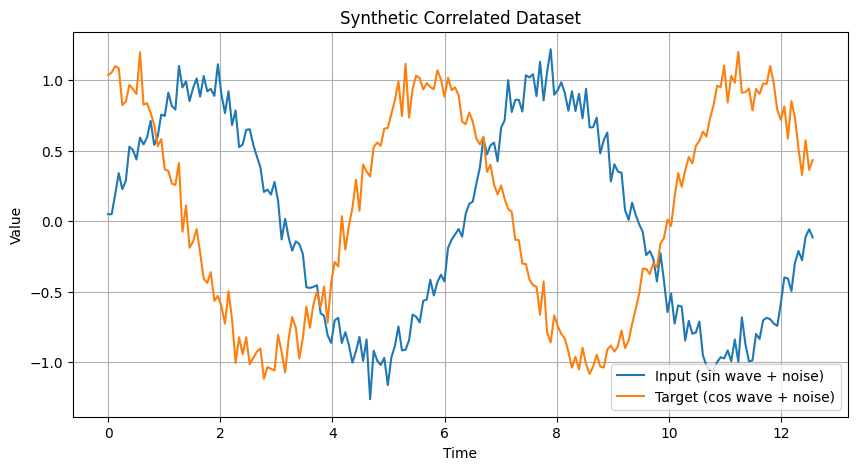

In [ ]:
# 1. Generate a synthetic dataset
sequence_length = 200
t = np.linspace(0, 4 * np.pi, sequence_length)
x_data = torch.tensor(np.sin(t) + np.random.randn(sequence_length) * 0.1, dtype=torch.float32).unsqueeze(1)
y_data = torch.tensor(np.cos(t * 1.1) + np.random.randn(sequence_length) * 0.1, dtype=torch.float32).unsqueeze(1)

# Let's assume a simple sequence prediction task: predict y from x
# For simplicity, we'll use x_data as input and y_data as target

print(f"x_data shape: {x_data.shape}")
print(f"y_data shape: {y_data.shape}")

plt.figure(figsize=(10, 5))
plt.plot(t, x_data.squeeze().numpy(), label='Input (sin wave + noise)')
plt.plot(t, y_data.squeeze().numpy(), label='Target (cos wave + noise)')
plt.title('Synthetic Correlated Dataset')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 2. Training Setup
d_model = x_data.shape[1]
d_hidden = 32
n_levels = 3
n_layers_per_mlp = 2
base_lr = 1e-3
base_chunk = 4
chunk_growth = 4

epochs = 500
outer_lr = 1e-2 # For overall model parameters, e.g., agg_weights

loss_fn = nn.MSELoss()

In [ ]:
# PyTorch Lightning Module for CMS models
class CMSLightningModule(pl.LightningModule):
    def __init__(self, cms_model_class, d_model, d_hidden, n_levels, n_layers_per_mlp, base_lr, base_chunk, chunk_growth, outer_lr):
        super().__init__()
        self.save_hyperparameters()
        self.cms_model = cms_model_class(
            d_model=d_model,
            d_hidden=d_hidden,
            n_levels=n_levels,
            n_layers_per_mlp=n_layers_per_mlp,
            base_lr=base_lr,
            base_chunk=base_chunk,
            chunk_growth=chunk_growth
        )
        self.loss_fn = nn.MSELoss()
        self.outer_lr = outer_lr
        self.automatic_optimization = False

    def forward(self, x):
        return self.cms_model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        opt = self.optimizers()

        output = self.cms_model(x)
        loss = self.loss_fn(output, y)

        self.manual_backward(loss)
        self.cms_model.accumulate_grads()
        self.cms_model.zero_grad()

        if opt is not None:
            opt.step()
            opt.zero_grad()

        self.log('train_loss', loss)
        return loss

    def on_train_start(self):
        # Ensure all MLPs' step counters are reset at the start of training
        for m in self.cms_model.mlps:
            m.zero_step_counter()
        if isinstance(self.cms_model, NestedCMS):
            self.cms_model.save_all_init()

    def on_train_batch_end(self, outputs, batch, batch_idx):
        # This is where the inner loop update happens after gradients are computed for the batch
        # and before the optimizer.step() if using manual optimization or for internal updates.
        # PyTorch Lightning handles model.zero_grad() and optimizer.step()
        # We need to manually trigger the cms_model's step_update which performs inner loop updates.
        self.cms_model.step_update()

    def configure_optimizers(self):
        if isinstance(self.cms_model, IndependentCMS):
            # Only IndependentCMS has outer trainable parameters (agg_weights) that need an optimizer
            print(f"Optimizing agg_weights with lr={self.outer_lr}")
            return torch.optim.Adam([self.cms_model.agg_weights], lr=self.outer_lr)
        # For SequentialCMS and NestedCMS, learning is handled internally by MemoryMLPs,
        # so no explicit outer optimizer is needed here for the main model parameters.
        # Lightning will still manage the training loop even without an optimizer.
        return None

In [ ]:
dataset = TensorDataset(x_data, y_data)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=6) # Batch size 1 for sequential processing

In [ ]:
def train_lightning_cms_model(cms_model_class, name):
    print(f"\n--- Training {name} with PyTorch Lightning ---")
    model = CMSLightningModule(
        cms_model_class=cms_model_class,
        d_model=d_model,
        d_hidden=d_hidden,
        n_levels=n_levels,
        n_layers_per_mlp=n_layers_per_mlp,
        base_lr=base_lr,
        base_chunk=base_chunk,
        chunk_growth=chunk_growth,
        outer_lr=outer_lr
    )

    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator=DEVICE,
        enable_checkpointing=False, # Disable checkpointing for this example
        logger=False, # Disable logger for this example
        enable_progress_bar=False # Disable progress bar for cleaner output
    )

    trainer.fit(model, dataloader)

    # Manually extract losses for plotting, as logging is disabled
    # A more robust solution would use a logger (e.g., CSVLogger)
    # For this example, we'll run a quick inference pass to get the final loss curve
    # This is a simplification; actual logged metrics would be better.

    model.to(DEVICE)
    model.eval()
    losses = []
    with torch.no_grad():
        for x, y in dataloader:
            output = model(x.to(DEVICE))
            loss = model.loss_fn(output, y.to(DEVICE))
            losses.append(loss.item())

    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.title(f'{name} Training Loss Over Epochs (Lightning)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True)
    plt.show()

    return model, losses

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



--- Training IndependentCMS with PyTorch Lightning ---


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Optimizing agg_weights with lr=0.01


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ cms_model │ IndependentCMS │    294 │ train │     0 │
│ 1 │ loss_fn   │ MSELoss        │      0 │ train │     0 │
└───┴───────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 294                                                                                              
Non-trainable params: 0                                                                                            
Total params: 294                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=500` reached.


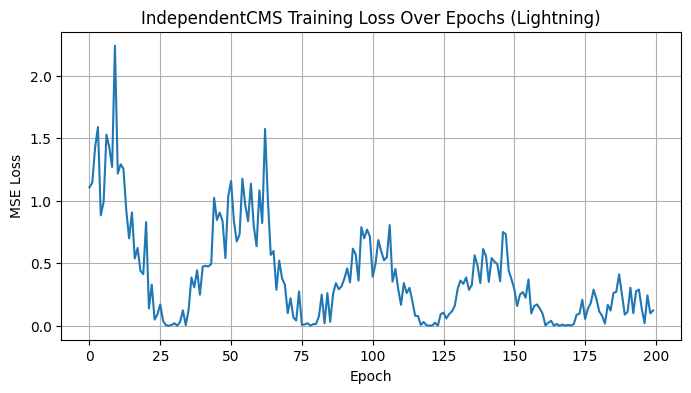

In [ ]:
independent_cms_pl, ind_losses_pl = train_lightning_cms_model(IndependentCMS, "IndependentCMS")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



--- Training SequentialCMS with PyTorch Lightning ---


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ cms_model │ SequentialCMS │    291 │ train │     0 │
│ 1 │ loss_fn   │ MSELoss       │      0 │ train │     0 │
└───┴───────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 291                                                                                              
Non-trainable params: 0                                                                                            
Total params: 291                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=500` reached.


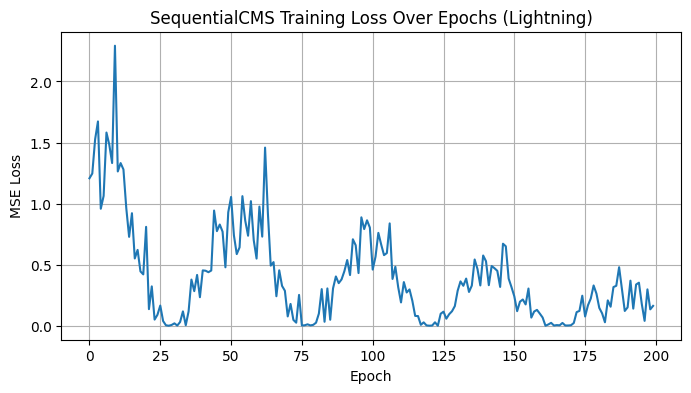

In [ ]:
sequential_cms_pl, seq_losses_pl = train_lightning_cms_model(SequentialCMS, "SequentialCMS")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



--- Training NestedCMS with PyTorch Lightning ---


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ cms_model │ NestedCMS │    291 │ train │     0 │
│ 1 │ loss_fn   │ MSELoss   │      0 │ train │     0 │
└───┴───────────┴───────────┴────────┴───────┴───────┘

Trainable params: 291                                                                                              
Non-trainable params: 0                                                                                            
Total params: 291                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=500` reached.


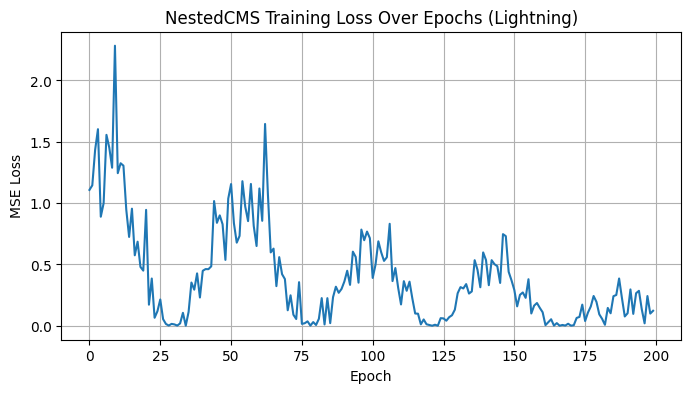

In [ ]:
nested_cms_pl, nes_losses_pl = train_lightning_cms_model(NestedCMS, "NestedCMS")

In [ ]:
# Evaluate and visualize predictions (optional, could be a separate step)
def evaluate_model(model, name):
    model.to(DEVICE)
    model.eval()
    model.to(DEVICE)
    predictions = []
    with torch.no_grad():
        for i in range(sequence_length):
            input_val = x_data[i:i+1].to(DEVICE)
            output = model(input_val)
            predictions.append(output.cpu().numpy().item())

    plt.figure(figsize=(10, 5))
    plt.plot(t, y_data.squeeze().numpy(), label='True Target')
    plt.plot(t, predictions, label=f'{name} Predictions')
    plt.title(f'{name} Predictions vs True Target')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

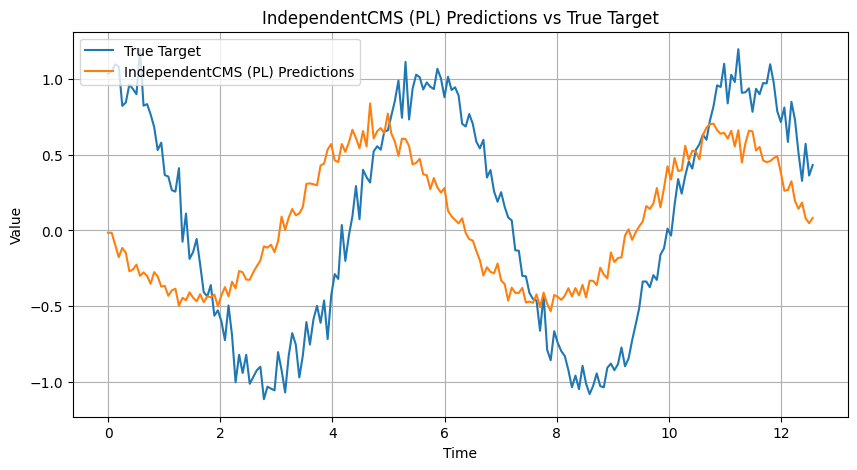

In [ ]:
evaluate_model(independent_cms_pl, "IndependentCMS (PL)")

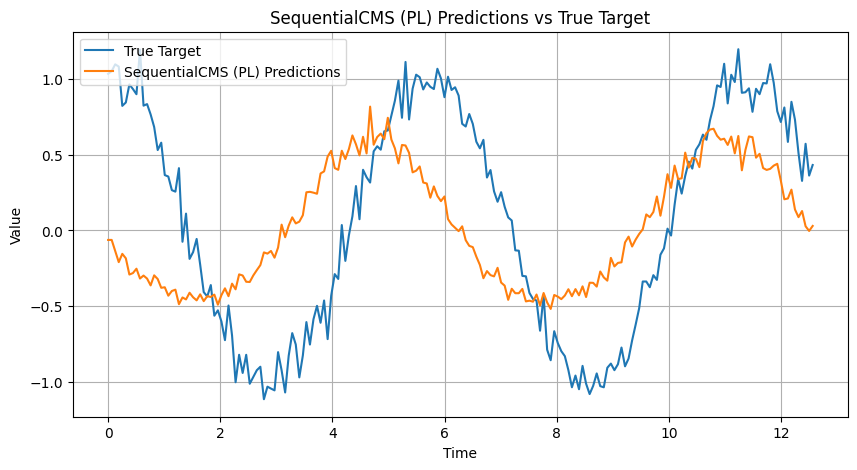

In [ ]:
evaluate_model(sequential_cms_pl, "SequentialCMS (PL)")


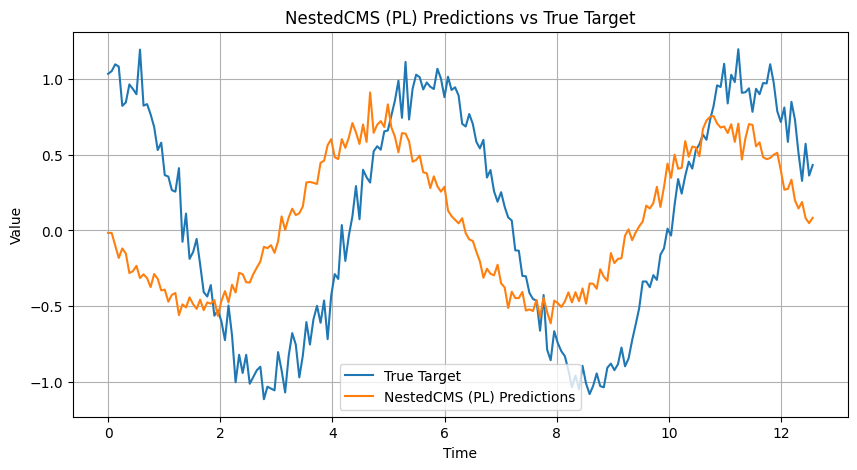

In [ ]:
evaluate_model(nested_cms_pl, "NestedCMS (PL)")